# Static Word embeddings and distributional similarity


In this practical session, we will explore static word embeddings.

 - We will make use of *gensim* for generating word embeddings.   
 - If you want to use your own computer you will need to make sure it is installed (e.g. using the command ```pip```).
 - If you’re using Anaconda/Miniconda, you can use the command ```conda install <modulename>```.

Documentation
- https://radimrehurek.com/gensim/auto_examples/index.html#documentation


In [2]:
%pip install -q gensim
%pip install -q fasttext

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install -q umap-learn

Note: you may need to restart the kernel to use updated packages.


## 1. Get pretrained static word embeddings

 - We  will  use *gensim* in  order  to  accessed pretrained  word  embeddings  from  text.   

   - *gensim* is  a  vector  space modeling and topic modeling toolkit for python.   
   - *gensim* contains efficient implementations of some embeddings training algorithms (word2vec, fasttext).   
   - *gensim* can load pretrained models (e.g. glove).
   
 - We will use glove as it is lighter, but you can try with fasttext at home.  


In [1]:
import gensim
import fasttext.util
from tqdm import tqdm

# bigger model (4G) -> a bit slow on colab
# fasttext.util.download_model('en', if_exists='ignore')  # English

# small glove
#import gensim.downloader as api
#model = api.load("glove-wiki-gigaword-100") #50, 100, 200, 300

# Chargement d'un modèle pré-entraîné
model_ = fasttext.load_model('cc.en.300.bin')

### Print information about the model learned

▶▶ 
- Print the vocabulary and then the vectors for a few terms, e.g. 'citron' and 'fruit'. 
- Do they seem close?

In [2]:
vocabulary = model_.get_words()
print(len(vocabulary))
print(vocabulary[:100])

2000000
[',', 'the', '.', 'and', 'to', 'of', 'a', '</s>', 'in', 'is', ':', 'I', 'for', 'that', ')', '"', '(', 'on', 'with', 'it', 'you', 'The', 'was', 'as', 'are', 'at', '/', '’', 'be', 'by', "'s", 'this', 'have', 'from', 'or', '!', 'not', 'your', 'an', "'", 'but', '?', 'can', '-', 'will', 's', 'my', 'has', 'all', 'we', 'they', 'he', 'his', 'more', 'one', 'about', 'their', "'t", 'so', 'which', 'It', 'out', 'up', '...', 'were', 'had', 'who', 'like', ';', '“', 'our', 'would', '”', 'time', 'been', 'if', 'also', 'just', 'when', 'her', 'This', 'me', 'there', 'do', 'what', 'some', 'other', 'In', 'them', '–', '1', 'get', 'new', 'into', '&', 'We', 'than', 'A', 'no', 'only']


In [11]:
print(f'Lemon : {model_["lemon"].shape}  {model_["lemon"][:5]}')
print(f'Fruit : {model_["fruit"].shape}  {model_["fruit"][:5]}')

Lemon : (300,)  [-0.11199058 -0.13555713 -0.1444709   0.07196344  0.07515837]
Fruit : (300,)  [ 0.00351589 -0.01181719  0.01954382  0.12996884  0.0517986 ]


## 2. Compute word similarity

You can now compute similarity measure between words.   
 
 - The similarity is measured by cosine similarity between the word vectors.
 - The similarity between 2 words can be computed using the code below:



In [12]:
import fasttext
import numpy as np

# Fonction pour calculer la similarité cosinus
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# Obtention des vecteurs pour "chat" et "chien"
vec_1 = model_.get_word_vector("eat")
vec_2 = model_.get_word_vector("drink")

# Calcul de la similarité
similarity = cosine_similarity(vec_1, vec_2)
print(f"Fasttext le calcul de la similarité entre 'eat' et 'drink' est : {similarity}")

# Trouver les mots les plus similaires
similar_words = model_.get_nearest_neighbors("eat", k=5)
print("Mots les plus similaires à 'eat':", similar_words)

Fasttext le calcul de la similarité entre 'eat' et 'drink' est : 0.5541635751724243
Mots les plus similaires à 'eat': [(0.7048296928405762, 'ate'), (0.7042676210403442, 'eating'), (0.6950281262397766, 'eat.But'), (0.6935786604881287, 'eats'), (0.6878792643547058, 'eat.So')]


In [13]:
from gensim.models.fasttext import load_facebook_model
model = load_facebook_model('cc.en.300.bin')

You can also print the most similar words by issuing the following command :

In [14]:
similarity = model.wv.similarity('eat', 'drink')
print(f"Word2Vect la similarité entre 'eat' et 'drink' est : {similarity}")

# Trouver les mots les plus similaires
similar_words = model.wv.most_similar("eat")
print("Mots les plus similaires à 'eat':", similar_words)

Word2Vect la similarité entre 'eat' et 'drink' est : 0.5541636347770691
Mots les plus similaires à 'eat': [('ate', 0.7048295736312866), ('eating', 0.704267680644989), ('eat.But', 0.6950280666351318), ('eats', 0.6935787796974182), ('eat.So', 0.6878795027732849), ('eaten', 0.6624336242675781), ('eat.If', 0.6617840528488159), ('eat.What', 0.6603627800941467), ('eat.When', 0.6590897440910339), ('eat.And', 0.6581928133964539)]


▶▶
- Print the similarity between some terms that seem to have close meaning or not.
- Do the results seem coherent?

In [15]:
similarity = model.wv.similarity('sunny', 'shine')
print(f"Word2Vect la similarité entre 'sunny' et 'shine' est : {similarity}")
similarity = model.wv.similarity('computer', 'calculator')
print(f"Word2Vect la similarité entre 'computer' et 'calculator' est : {similarity}")
similarity = model.wv.similarity('work', 'labor')
print(f"Word2Vect la similarité entre 'work' et 'labor' est : {similarity}")

Word2Vect la similarité entre 'sunny' et 'shine' est : 0.23594287037849426
Word2Vect la similarité entre 'computer' et 'calculator' est : 0.34612661600112915
Word2Vect la similarité entre 'work' et 'labor' est : 0.34717869758605957


▶▶ 
 - Print the words that are most similar to: '_lemon_', '_eat_' and other words. 
 - Do the results seem coherent? 
 - Try to find a word with multiple senses.

In [16]:
# Trouver les mots les plus similaires
similar_words = model.wv.most_similar("lemon")
similarity = model.wv.similarity('lemon', 'lime')
print(f"Mots les plus similaires à 'lemon': {similar_words} \nSimilarité {similarity}")

# Trouver les mots les plus similaires
similar_words = model.wv.most_similar("eat")
similarity = model.wv.similarity('eat', 'ate')
print(f"Mots les plus similaires à 'eat': {similar_words} \nSimilarité {similarity}")

# Trouver un mot qui a plus sens
similar_words = model.wv.most_similar("bark")
similarity = model.wv.similarity('bark', 'Meow')
print(f"Mots les plus similaires à 'bark': {similar_words} \nSimilarité {similarity}")

Mots les plus similaires à 'lemon': [('lemons', 0.7369922995567322), ('lemon-', 0.7066901922225952), ('lemony', 0.6821563839912415), ('lemon.', 0.6782023310661316), ('citrus', 0.6593234539031982), ('lemon-infused', 0.6592174172401428), ('lime', 0.654977560043335), ('Lemon', 0.6518251895904541), ('lemon-y', 0.6494964957237244), ('grapefruit', 0.6398397088050842)] 
Similarité 0.654977560043335
Mots les plus similaires à 'eat': [('ate', 0.7048295736312866), ('eating', 0.704267680644989), ('eat.But', 0.6950280666351318), ('eats', 0.6935787796974182), ('eat.So', 0.6878795027732849), ('eaten', 0.6624336242675781), ('eat.If', 0.6617840528488159), ('eat.What', 0.6603627800941467), ('eat.When', 0.6590897440910339), ('eat.And', 0.6581928133964539)] 
Similarité 0.7048295736312866
Mots les plus similaires à 'bark': [('barks', 0.7138463258743286), ('bark.', 0.6715909838676453), ('bark-', 0.6618515849113464), ('bark-like', 0.6183951497077942), ('tree-bark', 0.6122559309005737), ('barkless', 0.604777

## 5. Analogical reasoning

As  we  saw  in  class,  word  embeddings  allow  us  to  do  analogical  reasoning  using  vector  addiction and subtraction. *gensim* offers the possibility to do so.

▶▶ 
- Try to perform analogical reasoning in the food  realm,  e.g. fork - food +  soup  = ?
- __Hint__  :  the  function  __most_similar()__  takes  arguments positive and negative.

▶▶ 
- Try the same using the function __most_similar_cosmul()__ 
- it performs a similar computation but uses multiplication and division instead, and see what works best

▶▶ 
- Try to find other operations between words
- All models use the same methods as word2vec
- See: 
   - https://tedboy.github.io/nlps/generated/generated/gensim.models.Word2Vec.most_similar.html
   - https://tedboy.github.io/nlps/generated/generated/gensim.models.Word2Vec.most_similar_cosmul.html

In [17]:
# Trouver un mot qui a plus sens
result = model.wv.most_similar(positive=['woman', 'king'], negative=['man'], topn=1)
print(f"positive=['woman', 'king'], negative=['man'] -> {result}")
result = model.wv.most_similar(negative=['fork','food'], positive=['soup'], topn=1)
print(f"positive=['food','fork'], negative=['soup'] -> {result}")

positive=['woman', 'king'], negative=['man'] -> [('queen', 0.7554813623428345)]
positive=['food','fork'], negative=['soup'] -> [('brothy', 0.2625659704208374)]


## 6. Visualize word embeddings

 - After we learn word embeddings from our text data or load an existing one, it can be nice to explore it with visualization.
 - You can use classical projection methods to reduce the high-dimensional word vectors to two-dimensional plots and plot them on a graph.
 - The visualizations can provide a qualitative diagnostic for your learned model.
 - We can then train a projection method on the vectors, such as those methods offered in scikit-learn, then use matplotlib to plot the projection as a scatter plot.
 - Let’s look at an example with Principal Component Analysis or PCA.
 - We're going to consider only a sample of the vocabulary so that it's quicker

In [18]:
import numpy as np

SAMPLE_SIZE = 10000
sample = np.random.choice(list(model.wv.key_to_index.keys()),SAMPLE_SIZE)

X = model.wv[sample]
print(X.shape)
print(sample[:10])

(10000, 300)
['Hachaim' 'enscribed' 'Denisovich' 'Chaminade-Madonna'
 'Îles-de-la-Madeleine' 'URLS' 'highly-configurable' 'rustle'
 'CelebrityHere' 'kbb-invoice-price']



We can create a 2-dimensional PCA model of the word vectors using the scikit-learn PCA class as follows.

In [19]:
from sklearn.decomposition import KernelPCA, PCA
from sklearn.manifold import TSNE
import umap

# quick but bad
pca = PCA(n_components=2)
%time result = pca.fit_transform(X)

CPU times: user 11.4 s, sys: 1.02 s, total: 12.4 s
Wall time: 1.4 s


__We can use more sophisticated reduction methods, for instance the two popular t-SNE and Umap__

  - https://scikit-learn.org/1.5/modules/generated/sklearn.manifold.TSNE.html
  - https://umap-learn.readthedocs.io/en/latest/

In [20]:
# TSNE: ~2mn on colab for sample_size = 10k
redux = TSNE(n_components=2)
# Umap: ~1mn
#redux = umap.UMAP(n_components=2)
%time result = redux.fit_transform(X)

AttributeError: 'NoneType' object has no attribute 'split'

In [21]:
import pandas as pds

df = pds.DataFrame(result,columns=['x','y'])
df["word"] = sample
df.head()

,x,y,word
0,0.002868,0.258116,Hachaim
1,-0.119485,-0.049523,enscribed
2,-0.107119,0.138989,Denisovich
3,-0.212615,-0.012437,Chaminade-Madonna
4,-0.210133,0.002715,Îles-de-la-Madeleine


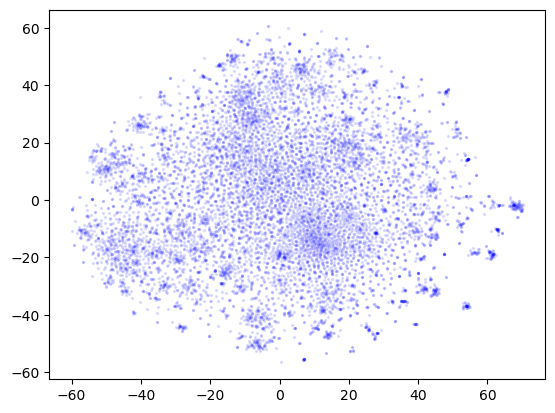

In [ ]:
from matplotlib import pyplot
# simple vizualisation
pyplot.scatter(result[:, 0], result[:, 1],alpha=0.1, s=2, c='blue', marker='o')
pyplot.show()

In [ ]:
%pip install -q plotly

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# a more interactive way to study the embeddings
import plotly.express as px

fig = px.scatter(df, x="x", y="y",
                 hover_name='word',
                width=800, height=600,
                template="seaborn")

fig.update_traces(opacity=.3)
fig.show()


#### 7. Embeddings sentences

Now that we have vectors to represent words, how can we represent sentences / sequences of words?

In [ ]:
import numpy as np

Below is given a set of sentences, some have a similar meanings: they are paraphrases.
We want to compute a representation for each sentence where similar sentences have a similar vector.

In [ ]:
sentence1 = "My disease was cured with a lot of medication"
sentence2 = "The weather is cold"
sentence3 = 'The sun is shining today'

▶▶ 
 - The code below compute a vector for a sentence based on a language model (= word embeddings).
 - How is the sentence vector computed? what is its shape?

In [ ]:
def encode(sentence,model):
    # Tokenize the sentence
    words = sentence.lower().split()    
    # Initialize matrix
    matrix = []    
    # Look up vector for each word and add to matrix
    for word in words:
        if word in model:
            vector = model[word]
            matrix.append(vector)
    
    # Convert list of vectors to numpy array
    return np.array(matrix)


Run the code below to compute vectors for the sentences above and **check that you found the right shape for the sentence vectors**.

In [ ]:
v1 = encode(sentence1,model.wv)
v2 = encode(sentence2,model.wv)
v3 = encode(sentence3,model.wv)
print(f' v1 : {v1.shape} v2 : {v2.shape}  v3 : {v3.shape}')

 v1 : (9, 300) v2 : (4, 300)  v3 : (5, 300)


:::

- Initialement le vecteur fait 9 lignes et 300 colonnes et on fait la moyenne des éléments des 9 lignes pour chacune des colonnes.  
  
- Cette opération peremt de réduire une représentation de phrase (composée de 9 vecteurs de mots) en un seul vecteur de phrase. 

- C'est une méthode simple pour obtenir une représentation vectorielle d'une phrase entière à partir des vecteurs de ses mots individuels.  

::: 

:::

- L'avantage de cette approche est qu'elle permet de comparer des phrases de différentes longueurs ( phrase de 9 mots avec une autre de 5) en utilisant des vecteurs de même dimension (300 dans ce cas). 

- Cependant, il est à de noter que cette méthode de moyenne perd l'information sur l'ordre des mots et peut ne pas capturer certaines nuances sémantiques.  

- Des méthodes plus avancées, comme l'utilisation de modèles de langue pré-entraînés (BERT, GPT, etc.), peuvent fournir des représentations de phrases plus sophistiquées qui prennent en compte le contexte et l'ordre des mots.
 
:::

The code below can be used to compute the cosine similarity between two sentence vectors:



In [ ]:
def cos(v1,v2):
  return np.dot(v1,v2, out=None)/(np.linalg.norm(v1)*np.linalg.norm(v2))

▶▶ 
 - Compute the similarity between the sentences given above. 
 - Are the results coherent?

In [ ]:

def sentence_vector(word_vectors):
    return np.mean(word_vectors, axis=0)

print(f'cos(v1,v2) {cos(sentence_vector(v1),sentence_vector(v2))}')
print(f'cos(v1,v3) {cos(sentence_vector(v1),sentence_vector(v3))}')
print(f'cos(v2,v3) {cos(sentence_vector(v2),sentence_vector(v3))}\n')

print(f'cos(v1,v2.T) {cos(v1,v2.T)[2,:5]}')
print(f'cos(v1,v3.T) {cos(v1,v3.T)[2,:5]}')
print(f'cos(v2,v3.T) {cos(v2,v3.T)[2,:5]}')

cos(v1,v2) 0.6438164114952087
cos(v1,v3) 0.599051833152771
cos(v2,v3) 0.8409923911094666

cos(v1,v2.T) [0.0272637  0.00495659 0.10034373 0.01535037]
cos(v1,v3.T) [0.02381872 0.0109173  0.08766455 0.00667255 0.01071634]
cos(v2,v3.T) [0.08341193 0.0325886  0.58955395 0.02634788 0.03492721]


## Evaluate the encoding on a corpus of paraphrases

We could use the sentence representations to check if two sentences are paraphrased of each other or not.

To verify this, we will use a corpus of existing labelled sentence pairs:

PAWS: Paraphrase Adversaries from Word Scrambling: https://huggingface.co/datasets/google-research-datasets/paws

Task: paraphrase identification: pairs of sentences are labeled as paraphrase or not.



In [ ]:
%pip install -q datasets

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from datasets import load_dataset
import pandas as pds

In [ ]:
dataset_train, dataset_val, dataset_test = load_dataset("paws", "labeled_final", split=['train', 'validation', 'test'])

In [ ]:
print(f"dataset_train : {dataset_train}")
print(f"dataset_train id {dataset_train['id'][1:2]}: {dataset_train['sentence1'][1:2]} label : {dataset_train['label'][1:2]}")
print(f"dataset_train id {dataset_train['id'][1:2]}: {dataset_train['sentence2'][1:2]} label : {dataset_train['label'][1:2]}")

dataset_train : Dataset({
    features: ['id', 'sentence1', 'sentence2', 'label'],
    num_rows: 49401
})
dataset_train id [2]: ['The NBA season of 1975 -- 76 was the 30th season of the National Basketball Association .'] label : [1]
dataset_train id [2]: ['The 1975 -- 76 season of the National Basketball Association was the 30th season of the NBA .'] label : [1]


In [ ]:
res={}

for one in tqdm(list(dataset_val)[:500]):
  id, s1, s2, label = one['id'], one['sentence1'], one['sentence2'], one["label"]
  v1, v2 = encode(s1,model.wv), encode(s2,model.wv)
  res[id] = cos(sentence_vector(v1),sentence_vector(v2)), label
  #print(res[id])

100%|██████████| 500/500 [00:00<00:00, 11017.35it/s]


In [ ]:
df = pds.DataFrame(res).T
df.columns = "sim","label"
df.head()

,sim,label
1,0.961155,0.0
2,0.997609,1.0
3,0.995881,1.0
4,0.980990,1.0
5,0.992339,1.0


To see if the similarity between sentences we compute can be useful to discriminate between paraphrases, let's have a look at the distribution of similarity scores for each class (0=not a paraphrase, 1=paraphrase).

What do you think ?

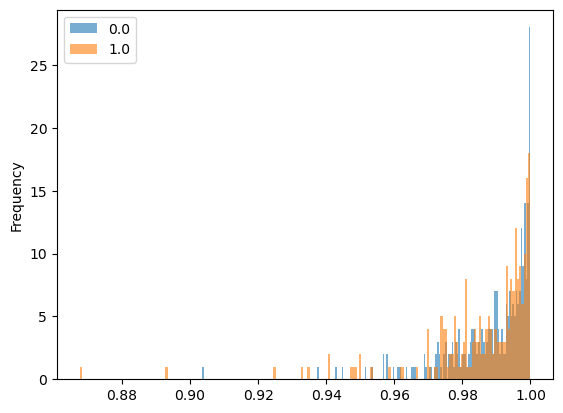

In [ ]:
import matplotlib.pyplot as plt

_ = df.groupby("label")["sim"].plot(kind="hist",bins=200,alpha=0.6,legend=True)

### Training a supervised classifier on sentence representation

A more expressive way would be to build a supervised classifier using the vector representation for both sentences as features. Let's try with a simple logistic regression : you can use
https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html

Conclusion: does this seem to work ?

We'll see much more powerful models for doing this later in the course.


In [ ]:
dataset = load_dataset("paws", "labeled_final")
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'sentence1', 'sentence2', 'label'],
        num_rows: 49401
    })
    test: Dataset({
        features: ['id', 'sentence1', 'sentence2', 'label'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['id', 'sentence1', 'sentence2', 'label'],
        num_rows: 8000
    })
})

__Recall : 0.2805 (28.05%)__
 - __Le modèle ci-dessous ne détecte que 28% des cas positifs réels, ce qui est assez faible.__

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Using CountVectorizer to convert sentences to vectors
train_sentences = [s1 + " " + s2 for s1, s2 in zip(dataset['train']['sentence1'], dataset['train']['sentence2'])]
valid_sentences = [s1 + " " + s2 for s1, s2 in zip(dataset['validation']['sentence1'], dataset['validation']['sentence2'])]
test_sentences =  [s1 + " " + s2 for s1, s2 in zip(dataset['test']['sentence1'], dataset['test']['sentence2'])]

# Vectorisation du texte :
vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(train_sentences + valid_sentences)
#X_valid = vectorizer.transform(valid_sentences)
X_test = vectorizer.transform(test_sentences)

y_train = dataset["train"]["label"] +  dataset["validation"]["label"]
y_test = dataset["test"]["label"] 

# Initialize the classifier
classifier = LogisticRegression(max_iter=1000)
# Train the model on the training set
classifier.fit(X_train, y_train)

# Making predictions on the test set
y_pred = classifier.predict(X_test)

# Calculating evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.551125
Precision: 0.4865129965669446
Recall: 0.28054298642533937
F1 Score: 0.3558744394618834


In [ ]:
def encode(sentence, model_wv, vector_size=100):
    words = sentence.split()
    vector = np.mean([model_wv[word] for word in words if word in model_wv], axis=0)
    return vector if vector.size else np.zeros(vector_size)

In [ ]:

from gensim.models.fasttext import load_facebook_model
model = load_facebook_model('cc.en.300.bin')

__Recall : 0.1881 (18.81%)__
 - __Le modèle ci-dessous ne détecte que 18.81% des cas positifs réels, ce qui est assez faible.__

In [ ]:
import numpy as np
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Using CountVectorizer to convert sentences to vectors
train_sentences = [encode(s1 + " " + s2,model.wv) for s1, s2 in zip(dataset['train']['sentence1'], dataset['train']['sentence2'])]
valid_sentences = [encode(s1 + " " + s2,model.wv) for s1, s2 in zip(dataset['validation']['sentence1'], dataset['validation']['sentence2'])]
test_sentences =  [encode(s1 + " " + s2,model.wv) for s1, s2 in zip(dataset['test']['sentence1'], dataset['test']['sentence2'])]

# Vectorisation du texte :
X_train = train_sentences + valid_sentences
X_test  = test_sentences
y_train = dataset["train"]["label"] + dataset["validation"]["label"]
y_test  = dataset["test"]["label"]

# Initialize the classifier
classifier = LogisticRegression(max_iter=1000)
# Train the model on the training set
classifier.fit(np.asarray(X_train), np.asarray(y_train))

# Making predictions on the test set
y_pred = classifier.predict(X_test)

# Calculating evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.565
Precision: 0.521978021978022
Recall: 0.1880656108597285
F1 Score: 0.2765072765072765


__Recall : 0.1881 (18.81%)__
 - __Le modèle ci-dessous ne détecte que 18.81% des cas positifs réels, ce qui est assez faible.__

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from gensim.models import Word2Vec

# Chargement des données
sentences1 = dataset['train']['sentence1'] + dataset['validation']['sentence1'] + dataset['test']['sentence1']
sentences2 = dataset['train']['sentence2'] + dataset['validation']['sentence2'] + dataset['test']['sentence2']
labels = dataset['train']['label'] + dataset['validation']['label'] + dataset['test']['label']

# Prétraitement (à adapter selon vos besoins)
def preprocess(sentence):
    # Implémentez votre logique de prétraitement ici
    return sentence.lower().split()

# Création du modèle Word2Vec
sentences = [preprocess(s1) + preprocess(s2) for s1, s2 in zip(sentences1, sentences2)]
word2vec_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

# Fonction pour obtenir le vecteur moyen d'une phrase
def get_sentence_vector(sentence):
    words = preprocess(sentence)
    word_vectors = [word2vec_model.wv[word] for word in words if word in word2vec_model.wv]
    if len(word_vectors) == 0:
        return np.zeros(word2vec_model.vector_size)
    return np.mean(word_vectors, axis=0)

# Création des features
X = np.array([np.concatenate([get_sentence_vector(s1), get_sentence_vector(s2)]) 
              for s1, s2 in zip(sentences1, sentences2)])
y = np.array(labels)

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraînement du modèle
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Évaluation
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(classification_report(y_test, y_pred))

Accuracy: 0.5776316795352038
Precision: 0.521978021978022
Recall: 0.1880656108597285
F1 Score: 0.2765072765072765
              precision    recall  f1-score   support

           0       0.59      0.85      0.69      7438
           1       0.52      0.22      0.31      5643

    accuracy                           0.58     13081
   macro avg       0.56      0.53      0.50     13081
weighted avg       0.56      0.58      0.53     13081



__Recall : 0.440 (44%)__
 - __Le modèle ci-dessous ne détecte que 44% des cas positifs réels, ce qui est assez moyen.__

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Using CountVectorizer to convert sentences to vectors
train_sentences = [s1 + " " + s2 for s1, s2 in zip(dataset['train']['sentence1'], dataset['train']['sentence2'])]
valid_sentences = [s1 + " " + s2 for s1, s2 in zip(dataset['validation']['sentence1'], dataset['validation']['sentence2'])]
test_sentences =  [s1 + " " + s2 for s1, s2 in zip(dataset['test']['sentence1'], dataset['test']['sentence2'])]

# Vectorisation du texte :
combined_sentences = train_sentences + valid_sentences
labels = dataset["train"]["label"] + dataset["validation"]["label"]
label_test  = dataset["test"]["label"]

# Initialisation et application de CountVectorizer
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(combined_sentences)
X_test  = vectorizer.transform(test_sentences)

# Conversion des labels en array numpy
y_train = np.array(labels)
y_test  = np.array(label_test)

# Initialize the classifier
classifier = LogisticRegression(max_iter=1000)
# Train the model on the training set
classifier.fit(X_train, y_train)

# Making predictions on the test set
y_pred = classifier.predict(X_test)

# Calculating evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(classification_report(y_test, y_pred))

Accuracy: 0.534125
Precision: 0.4711393170142037
Recall: 0.44089366515837103
F1 Score: 0.4555149744338933
              precision    recall  f1-score   support

           0       0.58      0.61      0.59      4464
           1       0.47      0.44      0.46      3536

    accuracy                           0.53      8000
   macro avg       0.52      0.52      0.52      8000
weighted avg       0.53      0.53      0.53      8000

